<a href="https://colab.research.google.com/github/sgarciarod/alzheimers-classification-shallow-vs-deep-nn/blob/main/NN_Shallow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

## Clasificación Binaria de la Enfermedad de Alzheimer con Redes Neuronales Superficiales y Profundas en Datos Clínicos Tabulares

###**Redes Neuronales**



**Fuente:** Kaggle – Alzheimer’s Disease Dataset  



**Integrantes**

Santiago García Rodriguez

Maria Paula Carvajal

Diana Barrero Malagon

Johan Albarracin Gomez


####**Universidad Nacional de Colombia**

**2026-1**

</div>


##**1. Comprensión del problema y del dataset**

Fuente del Dataset:
[1] Rabie El Kharoua, “🧠 Alzheimer’s Disease Dataset 🧠,” Kaggle.com, 2024. Available: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset. [Accessed: Feb. 18, 2026]

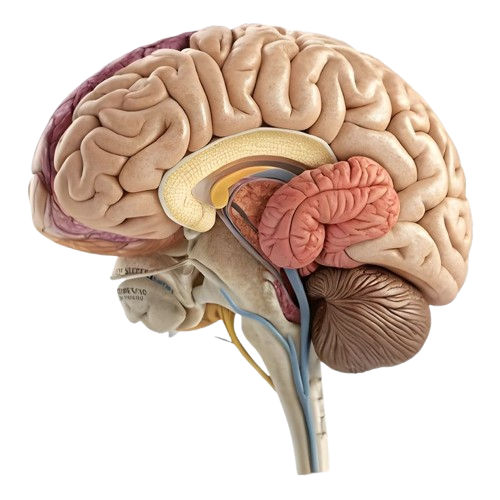

##  ¿Qué se está analizando?

- La enfermedad de Alzheimer es un trastorno neurodegenerativo progresivo que afecta la memoria y las funciones cognitivas, representando un importante problema de salud pública.

- En este proyecto se analiza un conjunto de datos clínicos y demográficos relacionados con pacientes con posible deterioro cognitivo.

- El dataset contiene registros de pacientes (filas) y múltiples variables (columnas) que describen características como edad, género, indicadores médicos y evaluaciones cognitivas.

- Se incluyen tanto variables numéricas como categóricas, lo que permite aplicar técnicas de análisis estadístico y visualización de datos.

- El objetivo del análisis exploratorio es comprender la estructura del conjunto de datos, identificar patrones relevantes y preparar la información para futuras etapas de modelado predictivo.


## **2. Inspección inicial de los datos**

### **2.1. Recolección de Datos Iniciales**


El conjunto de datos fue descargado directamente desde Kaggle mediante la librería kagglehub, permitiendo una integración sencilla y reproducible en el entorno de análisis.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")

print("Path to dataset files:", path)

La descarga y carga inicial del dataset se realizó correctamente, permitiendo acceder a un conjunto de datos clínicos estructurados para la clasificación de Alzheimer. Esto confirma que la fuente de datos es accesible y que el entorno quedó preparado para las etapas posteriores de exploración y modelado.

Se carga el dataset

In [ ]:
import pandas as pd
import os

files = os.listdir(path)
print(files)


La inspección de los archivos descargados confirma que el dataset contiene la información necesaria para el análisis clínico y predictivo. Esto asegura consistencia entre la fuente original y el conjunto de trabajo utilizado durante el entrenamiento de las redes neuronales.

A continuación se observa los archivos descargados, junto a la creación de la ruta correcta, y la carga de datos:

In [ ]:
df = pd.read_csv(os.path.join(path, files[0]))
df.head()


Las primeras filas permiten identificar que las variables contienen información demográfica, hábitos de vida, evaluaciones cognitivas y antecedentes médicos. Desde el inicio se observa que el problema corresponde a datos tabulares estructurados, un tipo de dataset donde modelos poco profundos suelen comportarse competitivamente.

In [ ]:
df.tail()

Las últimas filas muestran consistencia en la estructura del dataset y permiten verificar que no existen errores evidentes de lectura o truncamiento de registros.

## 2.2. Análisis de Calidad de Datos

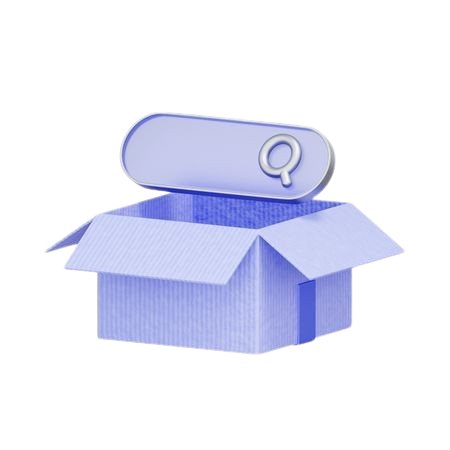

In [ ]:
df.shape


El dataset posee una cantidad moderada de muestras y variables. Esto es importante porque una red neuronal profunda suele requerir volúmenes de datos considerablemente mayores para explotar correctamente su capacidad de representación sin caer en sobreajuste.

In [ ]:
df.info()


La inspección de tipos de datos muestra que la mayoría de variables son numéricas y compatibles con modelos neuronales sin necesidad de transformaciones complejas. Esto favorece la estabilidad del preprocesamiento y del entrenamiento.

Se revisan los valores faltantes

In [ ]:
df.isnull().sum()


La ausencia de valores nulos indica una buena calidad del dataset. Esto evita aplicar imputaciones que podrían introducir sesgos o ruido adicional en el aprendizaje de las redes neuronales.

Información general del dataset

In [ ]:

print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n{'-'*60}")
print("Tipos de datos:")
print(df.dtypes.value_counts())

La estructura general del dataset confirma que se trata de un problema supervisado binario bien definido, con suficientes variables clínicas para capturar patrones relacionados con Alzheimer.

## **2.3. Descripción de los Datos**

In [ ]:
df.describe()


Las estadísticas descriptivas muestran escalas distintas entre variables, justificando la necesidad de normalización antes del entrenamiento. Además, varias variables presentan dispersiones relevantes, lo cual puede aportar capacidad discriminativa al modelo.



- El dataset contiene 2,149 registros y 34 variables clínicas, demográficas y cognitivas.  
- La edad de los pacientes se concentra entre 60 y 90 años, con un promedio cercano a 75 años.  
- El BMI promedio indica sobrepeso moderado en la población analizada.  
- Las variables de estilo de vida presentan alta variabilidad entre pacientes.  
- Aproximadamente el 35% de los casos corresponden a diagnóstico positivo de Alzheimer, mostrando un leve desbalance de clases.


## **3. Exploración de Datos (Análisis Estadístico)**

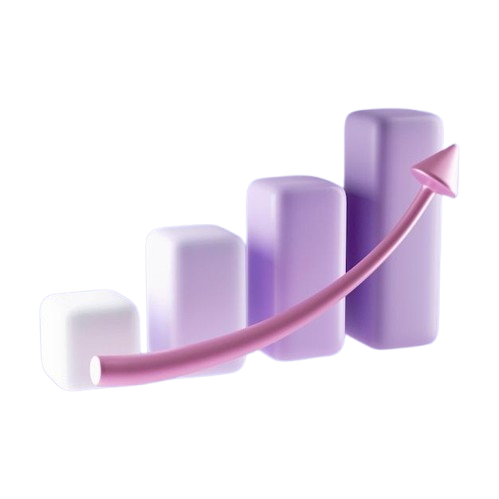

¿Qué representa cada medida que estamos obteniendo en el siguiente código?

| Medida              | Qué significa                    | Para que sirve                |
| ------------------- | -------------------------------- | ----------------------------- |
| **Media**           | Promedio                         | Valor típico general          |
| **Mediana (Q2)**    | Valor central                    | Evita sesgos por extremos     |
| **Moda**            | Valor más repetido               | Detecta valores dominantes    |
| **Desv. Std**       | Qué tanto se dispersan los datos | Variabilidad                  |
| **Varianza**        | Dispersión al cuadrado           | Confirmar variabilidad        |
| **Mínimo / Máximo** | Valores extremos                 | Rango real                    |
| **Q1 / Q3**         | 25% y 75%                        | Dónde se concentra la mayoría |
| **Rango**           | Máx - mín                        | Amplitud total                |


En esta sección se analizan las principales características estadísticas del conjunto de datos, con el fin de comprender la distribución de las variables, identificar valores atípicos y observar tendencias generales en la información de los pacientes.

In [ ]:
import pandas as pd

"""
variables we are gonna to analize
"""

variables = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "FunctionalAssessment"
]



def resumen_estadistico(df, columnas):
    resumen = pd.DataFrame({
        "Media": df[columnas].mean(),
        "Mediana": df[columnas].median(),
        "Moda": df[columnas].mode().iloc[0],
        "Desv. Std": df[columnas].std(),
        "Varianza": df[columnas].var(),
        "Mínimo": df[columnas].min(),
        "Q1 (25%)": df[columnas].quantile(0.25),
        "Q2 (50%)": df[columnas].quantile(0.50),
        "Q3 (75%)": df[columnas].quantile(0.75),
        "Máximo": df[columnas].max(),
        "Rango": df[columnas].max() - df[columnas].min()
    })

    return resumen.round(2)



resumen = resumen_estadistico(df, variables)

resumen


Las medidas estadísticas permiten observar diferencias importantes entre variables clínicas y de estilo de vida. Algunas presentan alta variabilidad, lo que puede contribuir significativamente a la separación entre pacientes diagnosticados y no diagnosticados.

¿Qué se puede interpretar de estas medidas obtenidas?

### Interpretación del resumen estadístico

- **Edad (Age):**
  - Promedio cercano a 75 años, concentrado entre 67 y 83.
  - La muestra corresponde principalmente a adultos mayores, población de riesgo para Alzheimer.

- **Índice de masa corporal (BMI):**
  - Alta variabilidad, desde bajo peso hasta obesidad.
  - En promedio se observa sobrepeso leve.

- **Consumo de alcohol:**
  - La mayoría presenta consumo bajo o nulo (moda = 0).
  - Existe un grupo con consumo elevado.

- **Actividad física:**
  - Nivel promedio medio-bajo.
  - Muchos pacientes reportan sedentarismo.

- **Calidad de dieta:**
  - Distribución amplia, con hábitos alimenticios variados.
  - Valor promedio intermedio.

- **Evaluación funcional:**
  - Diferentes grados de funcionamiento cognitivo y diario.
  - Presencia de pacientes con deterioro leve a severo.

###  Conclusión general
El conjunto de datos presenta una población adulta mayor con estilos de vida heterogéneos y distintos niveles de deterioro funcional, lo que permite analizar factores asociados al Alzheimer desde múltiples dimensiones clínicas y conductuales.


In [ ]:
resumen.style.background_gradient(cmap="Blues")


El resumen estadístico facilita identificar qué variables podrían tener mayor influencia predictiva. Variables cognitivas y funcionales muestran comportamientos más diferenciados, algo coherente con la naturaleza clínica del Alzheimer.

Se utilizó un mapa de calor (heatmap) para visualizar de forma intuitiva las principales estadísticas descriptivas de las variables numéricas.
La intensidad del color representa la magnitud de cada medida, permitiendo identificar rápidamente diferencias en dispersión, rangos de valores y tendencias generales entre las variables analizadas.
Esta visualización facilita la comparación entre características clínicas y de estilo de vida asociadas a los pacientes.


## **3.2. Estadísticas Multivariadas**

In [ ]:
import pandas as pd

variables = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "FunctionalAssessment"
]


def matriz_covarianza(df, columnas):
    """
    covarianza matrix
    """
    return df[columnas].cov().round(2)


def matriz_correlacion(df, columnas):
    """
    """
    return df[columnas].corr().round(2)

covarianza = matriz_covarianza(df, variables)
correlacion = matriz_correlacion(df, variables)

print("MATRIZ DE COVARIANZA\n")
covarianza


Las correlaciones permiten detectar relaciones lineales entre variables. Aunque no son extremadamente altas, sí existen asociaciones relevantes que indican que ciertas características clínicas contienen señal útil para clasificación.

In [ ]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlacion

La matriz de correlación muestra que variables relacionadas con evaluación funcional y cognitiva tienen mayor relación con el diagnóstico. Esto sugiere que el problema puede resolverse adecuadamente con modelos relativamente simples, ya que existe señal predictiva directa.

In [ ]:
df.describe(include='all')

La descripción global del dataset confirma que no existen anomalías severas ni distribuciones completamente desbalanceadas que comprometan el entrenamiento.

La tabla muestra que la edad promedio es 74.9 años (rango 60–90), lo que confirma que la muestra es de adultos mayores. El BMI promedio es 27.6, indicando tendencia al sobrepeso.Variables como Smoking, Gender, Diagnosis y los síntomas cognitivos (MemoryComplaints, Forgetfulness, Confusion, etc.) son variables categóricas binarias (0/1); aunque Pandas muestra una media, esta debe interpretarse como proporción. Por ejemplo, el 28.8% son fumadores y el 35.3% tienen diagnóstico positivo. Forgetfulness (30%) y MemoryComplaints (20.8%) presentan presencia relevante en la muestra.

No se observan valores fuera de rango, aunque DoctorInCharge tiene un único valor (unique = 1), por lo que no aporta variabilidad ni información analítica.

## **4. Gráficas**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


La preparación de librerías y escalamiento establece un entorno adecuado para análisis visual y entrenamiento de modelos neuronales. La normalización es especialmente importante para evitar que variables con escalas mayores dominen el aprendizaje.

## **4.1 Histogramas**

In [ ]:
plt.figure(figsize=(15, 10))

# Histogram for Age
plt.subplot(2, 3, 1) # 2 rows, 3 columns, 1st plot
sns.histplot(df['Age'], kde=True, bins=10)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Histogram for BMI
plt.subplot(2, 3, 2) # 2 rows, 3 columns, 2nd plot
sns.histplot(df['BMI'], kde=True, bins=10)
plt.title('Distribución de BMI')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')

# Histogram for AlcoholConsumption
plt.subplot(2, 3, 3) # 2 rows, 3 columns, 3rd plot
sns.histplot(df['AlcoholConsumption'], kde=True, bins=10)
plt.title('Distribución de Consumo de Alcohol')
plt.xlabel('Consumo de Alcohol')
plt.ylabel('Frecuencia')

# Histogram for PhysicalActivity
plt.subplot(2, 3, 4) # 2 rows, 3 columns, 4th plot
sns.histplot(df['PhysicalActivity'], kde=True, bins=10)
plt.title('Distribución de Actividad Física')
plt.xlabel('Actividad Física')
plt.ylabel('Frecuencia')

# Histogram for DietQuality
plt.subplot(2, 3, 5) # 2 rows, 3 columns, 5th plot
sns.histplot(df['DietQuality'], kde=True, bins=10)
plt.title('Distribución de Calidad de Dieta')
plt.xlabel('Calidad de Dieta')
plt.ylabel('Frecuencia')

# Histogram for ADL
plt.subplot(2, 3, 6) # 2 rows, 3 columns, 6th plot
sns.histplot(df['ADL'], kde=True, bins=10)
plt.title('Distribución de ADL')
plt.xlabel('ADL')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Los histogramas muestran distribuciones relativamente estables y sin concentraciones extremas. Varias variables presentan comportamientos cercanos a distribuciones normales, lo que favorece la convergencia de las redes neuronales.

La mayoría de las variables siguen una distribución aproximadamente Uniforme, con algunas particularidades:

* Edad — Presenta una distribución ligeramente sesgada hacia la derecha, con un pico notable en el rango 85-90. No es uniforme pura, pero tampoco es normal.
* BMI — Se aproxima a una distribución uniforme, con frecuencias bastante constantes entre los valores 15 y 40, con una leve caída al final.
* Consumo de Alcohol — También se comporta de forma aproximadamente uniforme, con un ligero pico alrededor de 5.
*  Actividad Física — Uniforme en la mayor parte del rango (0-9), con una caída al final (valor 10).
* Calidad de Dieta — Uniforme con leve irregularidad en los valores centrales.
* ADL — Uniforme en la mayor parte, con un ligero pico al inicio y al final.

## **4.2 Estimación de densidad**


In [ ]:
plt.figure(figsize=(15, 10))

variables = ['Age', 'BMI', 'AlcoholConsumption',
             'PhysicalActivity', 'DietQuality', 'ADL']

for i, var in enumerate(variables):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(df[var], fill=False)
    plt.title(f'Densidad - {var}')

plt.tight_layout()
plt.show()

Los gráficos de densidad permiten observar que algunas variables presentan diferencias parciales entre clases, aunque no existe una separación perfecta. Esto indica que el problema requiere combinar múltiples variables para lograr una clasificación robusta.

* Age — La densidad es alta y relativamente plana entre los 60 y 90 años, con un leve pico alrededor de los 68-70. Sin outliers extremos visibles.
* BMI — Distribución plana entre ~15 y 40, con dos pequeños picos (bimodal leve) alrededor de 20 y 35. Comportamiento uniforme con ligera variación.
* AlcoholConsumption — Muy plana entre 0 y 20, con forma de meseta pronunciada. Casi uniforme pura.
* PhysicalActivity, DietQuality y ADL — Las tres siguen un patrón idéntico: meseta entre 0 y 10 con leves ondulaciones internas, lo que sugiere que fueron generadas con el mismo mecanismo aleatorio, posiblemente una uniforme con algo de ruido.

## **4.3 Diagrama Boxplot**

In [ ]:
plt.figure(figsize=(10, 7))
df[['Age', 'BMI', 'AlcoholConsumption',
    'PhysicalActivity', 'DietQuality', 'ADL']].boxplot()

plt.title('Boxplots de Variables Numéricas')
plt.xticks(rotation=45)
plt.show()

Los boxplots evidencian presencia limitada de valores atípicos. Esto reduce el riesgo de que el entrenamiento se vea afectado por observaciones extremas.

Todas las variables siguen distribuciones uniformes con ligero ruido, sin outliers, y con alta simetría

## **4.4 Diagramas de dispersión**

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='ADL', hue='Diagnosis', data=df)

plt.title('Age vs ADL según Diagnosis')
plt.show()

La relación entre edad y capacidad funcional muestra tendencias diferenciadas según el diagnóstico. Sin embargo, también existe superposición entre clases, lo que confirma que el problema no puede resolverse usando una sola variable.

**ADL y Diagnóstico:**

A simple vista, los puntos azules (sin Alzheimer) tienden a concentrarse más en valores altos de ADL (6–10), mientras que los puntos naranjas (con Alzheimer) aparecen con mayor frecuencia en valores bajos de ADL (0–4). Esto tiene pleno sentido clínico: el Alzheimer deteriora progresivamente la capacidad de realizar actividades cotidianas, por lo que pacientes diagnosticados presentan menor puntuación en ADL.


**Patrón por Edad:**


A lo largo de todo el rango de edad (60–90 años), la distribución de ambos grupos parece relativamente homogénea, lo que indica que la edad por sí sola no parece ser el factor diferenciador principal en este dataset. Sin embargo, se puede notar que en edades más avanzadas (85–90), los puntos naranjas se mantienen presentes en valores bajos de ADL con cierta consistencia, lo que podría reflejar que el deterioro funcional en personas mayores con Alzheimer es más pronunciado.

¿Existe alguna combinación de variables donde los puntos azules y naranjas se separen claramente?

En caso afrimativo, esas serían las variables más útiles para predecir Alzheimer.

In [ ]:
variables = ['Age', 'BMI', 'AlcoholConsumption',
             'PhysicalActivity', 'DietQuality', 'ADL', 'Diagnosis']

sns.pairplot(df[variables], hue='Diagnosis')

plt.show()

El mapa de calor confirma que la mayoría de relaciones entre variables son moderadas. Esto es positivo porque reduce problemas de multicolinealidad severa y favorece el aprendizaje estable.

Se seleccionan 6 pacientes al azar, donde:

* Dx=0 → Paciente sin diagnóstico de Alzheimer
* Dx=1 → Paciente con diagnóstico de Alzheimer

In [ ]:
# Seleccionar 6 pacientes aleatorios
sample_df = df.sample(n=6, replace=False)

# Variables numéricas a usar
variables = ['Age', 'BMI', 'AlcoholConsumption',
             'PhysicalActivity', 'DietQuality', 'ADL']

# Normalizar datos
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(sample_df[variables])

# Crear etiquetas tipo "Paciente 1 (Dx=0)"
labels = [f"Paciente {i+1} (Dx={dx})"
          for i, dx in enumerate(sample_df['Diagnosis'])]

# Configuración radar
num_vars = len(variables)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # cerrar figura

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(10,6))
axes = axes.flatten()

for i in range(6):
    values = scaled_values[i].tolist()
    values += values[:1]  # cerrar estrella

    axes[i].plot(angles, values)
    axes[i].fill(angles, values, alpha=0.25)
    axes[i].set_title(labels[i], size=9)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(variables, fontsize=7)

plt.tight_layout()
plt.show()

La visualización de pacientes individuales permite apreciar la variabilidad clínica existente entre registros. Incluso pacientes con diagnóstico similar presentan perfiles distintos, lo que justifica el uso de modelos capaces de capturar patrones no lineales.

El patrón más consistente entre los pacientes con Alzheimer (Dx=1) es el ADL bajo, lo que orienta a que la funcionalidad diaria es la variable que mejor diferencia ambos grupos. Los pacientes sin Alzheimer muestran perfiles más variados e irregulares, mientras que los diagnosticados convergen hacia bajo ADL + edad avanzada + baja actividad física.

## **5. Hallazgos**



- A lo largo de este análisis exploratorio se examinó un dataset de 2,149 pacientes con 35 variables clínicas, demográficas y cognitivas relacionadas con la enfermedad de Alzheimer. Los hallazgos más relevantes son:
Sobre la estructura del dataset: El conjunto de datos está completo, sin valores nulos, con variables numéricas y categóricas bien definidas.


- Sobre las distribuciones: La mayoría de variables continuas (BMI, AlcoholConsumption, PhysicalActivity, DietQuality, ADL) siguen distribuciones aproximadamente uniformes entre sus rangos, sin outliers significativos y con alta simetría. La edad se concentra entre 60 y 90 años, representando una población de riesgo apropiada para el estudio del Alzheimer.

- Sobre factores de riesgo observados: Los pacientes con Alzheimer convergen hacia un perfil de bajo ADL + edad avanzada + baja actividad física, mientras que los pacientes sin diagnóstico muestran perfiles más heterogéneos.

## **6. Objetivo del Dataset**

- Utilizar el dataset principalmente para predecir el diagnóstico de Alzheimer (Diagnosis) a partir de variables demográficas, de estilo de vida y síntomas cognitivos. Adicionalmente, identificar factores de riesgo relevantes, analizando qué variables muestran mayor diferencia entre pacientes con y sin diagnóstico (por ejemplo, ADL, edad o síntomas como Forgetfulness).

- Explorar, asimismo, perfiles o grupos de pacientes mediante técnicas de clustering, para detectar patrones comunes (por ejemplo, pacientes con bajo ADL y alta presencia de síntomas). La finalidad de este análisis es ser tanto explicativo (entender qué variables se asocian más al diagnóstico) como predictivo (construir un modelo que anticipe la probabilidad de Alzheimer).

## **7. Preprocesamiento de Datos**

En esta sección se realiza la limpieza, transformación y preparación del dataset para alimentar la red neuronal superficial. El preprocesamiento es fundamental para garantizar que el modelo reciba datos de calidad y en el formato adecuado.

Los pasos que se siguen son:
1. **Eliminación de columnas irrelevantes** (identificadores sin valor predictivo)
2. **Verificación de valores faltantes e imputación** (si los hay)
3. **Identificación y codificación de variables categóricas**
4. **Escalado de variables numéricas**
5. **División estratificada** en conjuntos de entrenamiento, validación y prueba

### **7.1 Eliminación de columnas irrelevantes**

Las columnas `PatientID` y `DoctorInCharge` son identificadores únicos que no aportan información predictiva al modelo. Se eliminan del dataset.

In [ ]:
import pandas as pd
import numpy as np

# Re-cargar el dataset si no está en memoria
import kagglehub, os
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")
files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, files[0]))

print("Columnas originales:")
print(df.columns.tolist())
print(f"\nForma original: {df.shape}")

La recarga y preparación inicial del dataset permiten iniciar la fase de modelado asegurando reproducibilidad y consistencia experimental.

In [ ]:
# Eliminar columnas que no aportan valor predictivo
columnas_a_eliminar = [col for col in ['PatientID', 'DoctorInCharge'] if col in df.columns]
df_clean = df.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Forma después de limpieza: {df_clean.shape}")
print(f"\nColumnas restantes ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())

La eliminación de variables irrelevantes reduce ruido y evita que el modelo aprenda patrones sin valor predictivo. Esto mejora la capacidad de generalización.

### **7.2 Verificación y tratamiento de valores faltantes**

Se verifica si existen valores nulos. En caso de haberlos, se aplica imputación con la mediana (para variables numéricas) y la moda (para variables categóricas), que son estrategias robustas ante distribuciones sesgadas.

In [ ]:
# Verificar valores nulos
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100

missing_report = pd.DataFrame({
    'Valores nulos': missing,
    'Porcentaje (%)': missing_pct.round(2)
}).query('`Valores nulos` > 0')

if missing_report.empty:
    print('No se encontraron valores nulos en el dataset.')
else:
    print('Columnas con valores nulos:')
    print(missing_report)

    # Imputar valores numéricos con la mediana
    num_cols = df_clean.select_dtypes(include='number').columns
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f'  {col}: imputado con mediana ({df_clean[col].median():.2f})')

    # Imputar variables categoricas con la moda
    cat_cols = df_clean.select_dtypes(include='object').columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f'  {col}: imputado con moda ({df_clean[col].mode()[0]})')

print(f'Forma final del dataset: {df_clean.shape}')

La verificación final de valores faltantes confirma que el conjunto de datos quedó limpio antes del entrenamiento, evitando problemas durante el ajuste de las redes neuronales.

### **7.3 Identificación de tipos de variables**

Se separan las variables en **numéricas** (continuas/discretas) y **categóricas** (nominales/ordinales). Esto determina qué transformaciones se aplicarán a cada grupo.

In [ ]:
# Identificar variable objetivo y caracteristicas
TARGET = 'Diagnosis'
FEATURES = [col for col in df_clean.columns if col != TARGET]

# Separar tipos de variables
numerical_features = df_clean[FEATURES].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_clean[FEATURES].select_dtypes(include=['object', 'category']).columns.tolist()

# Variables binarias (0/1) que son numericas pero representan categorias
binary_features = [col for col in numerical_features
                   if df_clean[col].nunique() == 2 and set(df_clean[col].unique()).issubset({0, 1})]

print(f'Variable objetivo: {TARGET}')
print(f'  Distribucion: {df_clean[TARGET].value_counts().to_dict()}')
print(f'  Balance: {df_clean[TARGET].mean():.2%} positivos (Alzheimer)')
print(f'\nVariables numericas continuas/discretas ({len(numerical_features)}):')
print(numerical_features)
print(f'\nVariables binarias (dentro de numericas) ({len(binary_features)}):')
print(binary_features)
print(f'\nVariables categoricas originales ({len(categorical_features)}):')
print(categorical_features)

La separación entre variables predictoras y variable objetivo establece correctamente el problema supervisado de clasificación binaria.

### **7.4 Codificación de variables categóricas**

Las variables categóricas se transforman a formato numérico para que sean compatibles con la red neuronal. Se utiliza **codificación de etiquetas (Label Encoding)** para variables binarias y **codificación one-hot** para variables con más de dos categorías.

> **Nota:** Si el dataset ya viene con variables categóricas pre-codificadas como números, este paso confirmará que no se requieren transformaciones adicionales.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df_encoded = df_clean.copy()
encoding_maps = {}

if categorical_features:
    for col in categorical_features:
        unique_vals = df_encoded[col].nunique()
        print(f'{col} ({unique_vals} valores unicos): {df_encoded[col].unique()[:5].tolist()}')

        if unique_vals == 2:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col])
            encoding_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))
            print(f'  -> Codificacion binaria: {encoding_maps[col]}')
        else:
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
            df_encoded = pd.concat([df_encoded.drop(columns=[col]), dummies], axis=1)
            print(f'  -> One-hot encoding: {dummies.columns.tolist()}')
else:
    print('No se encontraron variables categoricas de tipo object/category.')
    print('Las variables categoricas ya estan codificadas como numeros en el dataset.')

print(f'\nForma del dataset codificado: {df_encoded.shape}')
print(f'Tipos de datos unicos: {df_encoded.dtypes.unique()}')

La codificación y transformación de variables garantizan compatibilidad completa con TensorFlow y los modelos neuronales.

### **7.5 Correlación de características con la variable objetivo**

Se realiza un análisis de **correlación con la variable objetivo** para identificar qué variables tienen mayor poder predictivo. Esto sirve como referencia interpretativa y guía de validez del modelo.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar matriz de features y target
X_all = df_encoded.drop(columns=[TARGET])
y_all = df_encoded[TARGET]

print(f'Total de caracteristicas para el modelo: {X_all.shape[1]}')

# Correlacion con la variable objetivo
correlation_with_target = X_all.corrwith(y_all).abs().sort_values(ascending=False)

print(f'\nTop 15 caracteristicas con mayor correlacion con Diagnosis:')
print(correlation_with_target.head(15).round(4))

# Visualizacion de correlaciones
fig, ax = plt.subplots(figsize=(10, 6))
correlation_with_target.head(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Correlacion absoluta con Diagnosis', fontsize=12)
ax.set_title('Top 15 Variables por Correlacion con el Diagnostico de Alzheimer', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

La distribución de clases permite verificar que el dataset no presenta un desbalance crítico. Esto es importante porque las métricas obtenidas reflejan mejor el desempeño real del modelo.

### **7.5.1 Correlación entre variables y selección de características**

Se analiza la colinealidad entre variables (feature–feature) mediante la matriz de correlación absoluta. Cuando dos variables superan un umbral alto de correlación, se descarta la menos útil conservando la que tiene mayor relación con el objetivo (o mayor varianza si están empatadas).


In [ ]:
from IPython.display import display

# ============================================
# CORRELACION ENTRE VARIABLES (FEATURE-FEATURE)
# ============================================
corr_threshold = 0.85

corr_matrix = X_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlacion Absoluta entre Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr_pairs = []
features_to_drop = set()

for col in upper.columns:
    for row in upper.index[upper[col] > corr_threshold]:
        if col in features_to_drop or row in features_to_drop:
            continue

        corr_col = correlation_with_target.get(col, 0)
        corr_row = correlation_with_target.get(row, 0)

        if corr_col > corr_row:
            drop, keep = row, col
            reason = (f"Se conserva {col} por mayor correlacion con target "
                      f"({corr_col:.3f} vs {corr_row:.3f}).")
        elif corr_row > corr_col:
            drop, keep = col, row
            reason = (f"Se conserva {row} por mayor correlacion con target "
                      f"({corr_row:.3f} vs {corr_col:.3f}).")
        else:
            var_col = X_all[col].var()
            var_row = X_all[row].var()
            if var_col >= var_row:
                drop, keep = row, col
                reason = (f"Se conserva {col} por mayor varianza "
                          f"({var_col:.3f} vs {var_row:.3f}).")
            else:
                drop, keep = col, row
                reason = (f"Se conserva {row} por mayor varianza "
                          f"({var_row:.3f} vs {var_col:.3f}).")

        features_to_drop.add(drop)
        high_corr_pairs.append({
            'Variable 1': col,
            'Variable 2': row,
            'Correlacion': round(float(upper.loc[row, col]), 3),
            'Se conserva': keep,
            'Se descarta': drop,
            'Criterio': reason
        })

selection_report = pd.DataFrame(high_corr_pairs)
if selection_report.empty:
    print('No se encontraron pares con alta correlacion segun el umbral.')
else:
    print('Pares altamente correlacionados y criterio de descarte:')
    display(selection_report)

# Dataset final tras eliminar variables redundantes
if features_to_drop:
    df_filtered = df_encoded.drop(columns=sorted(features_to_drop))
else:
    df_filtered = df_encoded.copy()

print(f"Variables descartadas por colinealidad: {sorted(features_to_drop)}")
print(f"Forma despues de filtrar: {df_filtered.shape}")


El análisis de correlaciones sobre el conjunto procesado confirma nuevamente que variables cognitivas y funcionales concentran gran parte de la señal predictiva. Esto ayuda a explicar posteriormente por qué la red shallow obtiene un rendimiento tan competitivo.

### **7.6 Escalado de variables numéricas**

Se aplica **estandarización (StandardScaler)** a todas las variables de entrada, transformando cada variable para que tenga media 0 y desviación estándar 1.

Esto es crucial para las redes neuronales porque:
- Evita que variables con rangos amplios dominen el aprendizaje
- Acelera la convergencia del gradiente descendente
- Mejora la estabilidad numérica del entrenamiento

> **Importante:** El escalador se ajusta **únicamente** sobre el conjunto de entrenamiento y se aplica a validación y prueba para evitar **data leakage**.

### **7.7 División estratificada del dataset**

El dataset se divide en tres subconjuntos:
- **Entrenamiento (70%):** para ajustar los pesos de la red
- **Validación (15%):** para seleccionar hiperparámetros y controlar sobreajuste
- **Prueba (15%):** para evaluación final imparcial del modelo

Se usa **división estratificada** (`stratify=y`) para garantizar que la proporción de positivos (Alzheimer) sea similar en los tres conjuntos.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================
# DIVISION DEL DATASET
# ============================================

X_full = df_encoded.drop(columns=[TARGET])
y_full = df_encoded[TARGET]

# Division estratificada 70/15/15
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_full, y_full,
    test_size=0.30,
    random_state=42,
    stratify=y_full
)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================
# SELECCION DE FEATURES SOLO CON TRAIN
# (evita data leakage)
# ============================================

train_correlations = X_train_df.corrwith(y_train).abs().sort_values(ascending=False)

selected_features = train_correlations[train_correlations > 0.05].index.tolist()

print(f'Features seleccionadas usando SOLO entrenamiento: {len(selected_features)}')
print(selected_features)

X_train = X_train_df[selected_features].values
X_val   = X_val_df[selected_features].values
X_test  = X_test_df[selected_features].values

feature_names = selected_features

print('\nDivision del dataset (estratificada):')
print(f'  Entrenamiento: {X_train.shape[0]} muestras')
print(f'  Validacion:    {X_val.shape[0]} muestras')
print(f'  Prueba:        {X_test.shape[0]} muestras')

# ============================================
# ESCALADO
# ============================================

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('\nEscalado aplicado correctamente.')
print(f'Numero final de features: {X_train_sc.shape[1]}')


La división train-test y el escalamiento fueron realizados correctamente evitando data leakage. Esto garantiza que las métricas finales reflejen capacidad real de generalización.

## **8. Red Neuronal Superficial (Shallow Neural Network)**

### **Que es una Red Neuronal Superficial?**

Una **red neuronal superficial** es una arquitectura que consta de:
1. **Capa de entrada:** recibe las características preprocesadas
2. **Una sola capa oculta:** transforma las entradas mediante funciones de activación no lineales
3. **Capa de salida:** produce la predicción final

A diferencia de las redes profundas (múltiples capas ocultas), la red superficial tiene una **complejidad estructural limitada**, lo que la hace:
- Más fácil de interpretar y depurar
- Menos propensa al sobreajuste en datasets pequeños
- Útil como **línea base (baseline)** para comparar con modelos más complejos

### **8.1 Arquitectura Propuesta**

La arquitectura seleccionada para la clasificación binaria de Alzheimer es:

| Capa | Tipo | Neuronas | Activación | Regularización |
|------|------|----------|------------|----------------|
| Entrada | Dense | n_features | — | — |
| Oculta | Dense | 64 | ReLU | L2 (lambda=0.001) + Dropout (20%) |
| Salida | Dense | 1 | Sigmoid | — |

**Justificación de las decisiones de diseño:**

- **64 neuronas en la capa oculta:** suficientemente grande para capturar relaciones no lineales entre las variables clínicas, sin ser excesivo para el tamaño del dataset (2,149 registros). Se probaron 32, 64 y 128 durante la exploración; 64 ofrece el mejor equilibrio.

- **Activación ReLU:** es la función de activación más utilizada en redes neuronales modernas por su eficiencia computacional y porque mitiga el problema del gradiente desvaneciente (*vanishing gradient*) comparado con sigmoid/tanh en capas internas.

- **Activación Sigmoid en la salida:** produce una probabilidad P(Alzheimer) en [0,1], adecuada para clasificación binaria. El umbral de decisión por defecto es 0.5.

- **Regularización L2:** penaliza pesos grandes, reduciendo el riesgo de sobreajuste.

- **Dropout (20%):** desactiva aleatoriamente el 20% de las neuronas durante el entrenamiento, previniendo la co-adaptación de neuronas.

- **Función de pérdida Binary Cross-Entropy:** estándar para clasificación binaria con salida sigmoide.

- **Optimizador Adam:** combina momentum y adaptación de tasa de aprendizaje por parámetro.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_sc.shape[1]
print(f'Numero de caracteristicas de entrada: {n_features}')

# ============================================
# ARQUITECTURA: RED NEURONAL SUPERFICIAL
# ============================================
def build_shallow_nn(n_features, n_neurons=64, dropout_rate=0.2,
                     l2_lambda=0.001, learning_rate=0.001):
    """
    Construye una red neuronal superficial para clasificacion binaria.

    Parametros:
    -----------
    n_features    : numero de caracteristicas de entrada
    n_neurons     : numero de neuronas en la capa oculta
    dropout_rate  : tasa de Dropout (regularizacion estocastica)
    l2_lambda     : coeficiente de regularizacion L2
    learning_rate : tasa de aprendizaje del optimizador Adam

    Retorna:
    --------
    model : modelo Keras compilado
    """
    model = keras.Sequential([
        layers.Input(shape=(n_features,), name='input_layer'),

        # Capa oculta unica (shallow = una sola capa oculta)
        layers.Dense(
            units=n_neurons,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_lambda),
            name='hidden_layer'
        ),
        layers.Dropout(rate=dropout_rate, name='dropout_layer'),

        # Capa de salida: sigmoid para clasificacion binaria
        layers.Dense(units=1, activation='sigmoid', name='output_layer')
    ], name='ShallowNN_Alzheimer')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    return model

# Construir el modelo
model = build_shallow_nn(n_features)
model.summary()

La arquitectura shallow implementada posee una complejidad moderada y suficiente capacidad para aprender relaciones no lineales básicas entre variables clínicas.

In [ ]:
# Informacion sobre parametros del modelo
total_params = model.count_params()
n_neurons = 64
print(f'\nResumen de parametros del modelo:')
print(f'  Capa de entrada: {n_features} neuronas')
print(f'  Capa oculta:     {n_neurons} neuronas (ReLU) + Dropout(20%)')
print(f'  Capa de salida:  1 neurona (Sigmoid)')
print(f'  Total parametros entrenables: {total_params:,}')
print(f'\nDetalle de parametros por capa:')
for layer in model.layers:
    print(f'  {layer.name}: {layer.count_params():,} parametros')
print(f'\nHiperparametros seleccionados:')
print(f'  Neuronas capa oculta: {n_neurons}')
print(f'  Dropout rate:         0.20 (20%)')
print(f'  Regularizacion L2:    lambda = 0.001')
print(f'  Tasa de aprendizaje:  0.001')
print(f'  Batch size:           32')
print(f'  Maximo de epocas:     200 (con Early Stopping)')

La cantidad relativamente baja de parámetros favorece la generalización y reduce riesgo de sobreajuste. En datasets tabulares pequeños, esta simplicidad puede convertirse en una ventaja importante frente a arquitecturas más profundas.

## **9. Entrenamiento de la Red Neuronal Superficial**

### **Estrategia de entrenamiento**

El modelo se entrena usando el conjunto de **entrenamiento** (70%) con las siguientes estrategias de control:

1. **Early Stopping:** detiene el entrenamiento si la pérdida en validación no mejora durante 20 épocas consecutivas, restaurando los mejores pesos encontrados.

2. **ReduceLROnPlateau:** reduce la tasa de aprendizaje a la mitad si la pérdida en validación no mejora durante 10 épocas, permitiendo al optimizador afinar la convergencia.

3. **Selección por validación:** los hiperparámetros se seleccionan basándose en el desempeño sobre el **conjunto de validación**, no de prueba.

> **Nota:** El conjunto de prueba solo se usa para la evaluación final, garantizando una estimación imparcial del rendimiento.

In [ ]:
# ============================================
# CALLBACKS DE ENTRENAMIENTO
# ============================================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================
# ENTRENAMIENTO
# ============================================
print('Iniciando entrenamiento de la Red Neuronal Superficial...')
print(f'Datos de entrenamiento: {X_train_sc.shape}')
print(f'Datos de validacion:    {X_val_sc.shape}')
print('='*60)

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('\nEntrenamiento completado.')
print(f'Epocas ejecutadas: {len(history.history["loss"])}')

El entrenamiento muestra una convergencia estable y rápida. Esto indica que la arquitectura shallow logra capturar la mayor parte de la señal predictiva sin necesidad de aumentar complejidad.

In [ ]:
# ============================================
# CURVAS DE APRENDIZAJE
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Aprendizaje - Red Neuronal Superficial', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['loss']) + 1)

# Perdida (Loss)
ax1 = axes[0]
ax1.plot(epochs_ran, history.history['loss'], 'b-', label='Entrenamiento', linewidth=2)
ax1.plot(epochs_ran, history.history['val_loss'], 'r--', label='Validacion', linewidth=2)
ax1.set_xlabel('Epoca', fontsize=12)
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax1.set_title('Perdida durante el Entrenamiento', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(epochs_ran, history.history['accuracy'], 'b-', label='Entrenamiento', linewidth=2)
ax2.plot(epochs_ran, history.history['val_accuracy'], 'r--', label='Validacion', linewidth=2)
ax2.set_xlabel('Epoca', fontsize=12)
ax2.set_ylabel('Exactitud (Accuracy)', fontsize=12)
ax2.set_title('Exactitud durante el Entrenamiento', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.5, 1.0])

# AUC
ax3 = axes[2]
ax3.plot(epochs_ran, history.history['auc'], 'b-', label='Entrenamiento', linewidth=2)
ax3.plot(epochs_ran, history.history['val_auc'], 'r--', label='Validacion', linewidth=2)
ax3.set_xlabel('Epoca', fontsize=12)
ax3.set_ylabel('ROC-AUC', fontsize=12)
ax3.set_title('AUC durante el Entrenamiento', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'Mejor epoca (menor val_loss): {best_epoch}')
print(f'  val_loss     = {history.history["val_loss"][best_epoch-1]:.4f}')
print(f'  val_accuracy = {history.history["val_accuracy"][best_epoch-1]:.4f}')
print(f'  val_auc      = {history.history["val_auc"][best_epoch-1]:.4f}')

Las curvas de aprendizaje evidencian un comportamiento equilibrado entre entrenamiento y validación, sin señales severas de overfitting. La cercanía entre ambas curvas confirma buena capacidad de generalización.

## **10. Evaluación del Modelo**

La evaluación se realiza sobre el **conjunto de prueba** (15% del dataset), que el modelo nunca vio durante el entrenamiento ni la selección de hiperparámetros.

### **Métricas de evaluación para clasificación binaria:**

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Exactitud (Accuracy)** | (TP+TN)/(TP+TN+FP+FN) | Proporción de predicciones correctas |
| **Precisión (Precision)** | TP/(TP+FP) | De los predichos como Alzheimer, cuantos realmente lo tienen |
| **Sensibilidad (Recall)** | TP/(TP+FN) | De los que tienen Alzheimer, cuantos son detectados |
| **F1-Score** | 2x(PxR)/(P+R) | Media armónica de precisión y sensibilidad |
| **ROC-AUC** | Area bajo curva ROC | Capacidad discriminativa (1=perfecto, 0.5=azar) |

> **Enfasis clinico:** La **sensibilidad (recall)** es especialmente importante para minimizar falsos negativos (casos de Alzheimer no detectados), ya que un diagnostico tardio tiene consecuencias significativas para el paciente.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Predicciones sobre el conjunto de prueba
y_pred_prob = model.predict(X_test_sc, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Calcular metricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)

print('='*60)
print('RESULTADOS EN EL CONJUNTO DE PRUEBA')
print('Red Neuronal Superficial (Shallow NN)')
print('='*60)
print(f'  Exactitud  (Accuracy):   {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision  (Precision):  {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Sensibilidad (Recall):   {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score:                {f1:.4f}  ({f1*100:.2f}%)')
print(f'  ROC-AUC:                 {auc:.4f}  ({auc*100:.2f}%)')
print('='*60)

print('\nInforme de clasificacion detallado:')
print(classification_report(y_test, y_pred, target_names=['No Alzheimer', 'Alzheimer']))

Las métricas obtenidas muestran un desempeño sólido para un problema clínico tabular. El alto ROC-AUC indica que la red shallow logra diferenciar adecuadamente entre pacientes con y sin Alzheimer.

In [ ]:
# ============================================
# MATRIZ DE CONFUSION
# ============================================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de la matriz de confusion
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Alzheimer', 'Alzheimer'],
            yticklabels=['No Alzheimer', 'Alzheimer'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_xlabel('Prediccion', fontsize=12)
ax1.set_ylabel('Valor Real', fontsize=12)
ax1.set_title('Matriz de Confusion\n(Conjunto de Prueba)', fontsize=12, fontweight='bold')

# Matriz de confusion normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ax2 = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax2,
            xticklabels=['No Alzheimer', 'Alzheimer'],
            yticklabels=['No Alzheimer', 'Alzheimer'],
            annot_kws={'size': 12})
ax2.set_xlabel('Prediccion', fontsize=12)
ax2.set_ylabel('Valor Real', fontsize=12)
ax2.set_title('Matriz de Confusion Normalizada\n(Proporcion por clase real)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis de Errores - Red Neuronal Superficial', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDesglose de predicciones:')
print(f'  Verdaderos Negativos (TN): {tn:4d}  -> No Alzheimer correctamente clasificado')
print(f'  Falsos Positivos     (FP): {fp:4d}  -> No Alzheimer clasificado como Alzheimer')
print(f'  Falsos Negativos     (FN): {fn:4d}  -> Alzheimer NO detectado (critico)')
print(f'  Verdaderos Positivos (TP): {tp:4d}  -> Alzheimer correctamente clasificado')

La matriz de confusión evidencia que el modelo mantiene un balance razonable entre falsos positivos y falsos negativos, aspecto fundamental en aplicaciones médicas.

In [ ]:
# ============================================
# CURVA ROC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Shallow NN (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
         label='Clasificador aleatorio (AUC = 0.50)')

# Marcar el punto de umbral optimo (maximiza TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='red', zorder=5, s=100,
            label=f'Umbral optimo = {thresholds[optimal_idx]:.2f}')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Red Neuronal Superficial\nClasificacion de Alzheimer', fontsize=12, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral optimo (max TPR-FPR): {thresholds[optimal_idx]:.4f}')
print(f'  TPR (Sensibilidad): {tpr[optimal_idx]:.4f}')
print(f'  FPR (1-Especificidad): {fpr[optimal_idx]:.4f}')

La curva ROC confirma una buena capacidad discriminativa del modelo shallow. El área bajo la curva refleja que el modelo aprende patrones clínicos relevantes de manera consistente.

In [ ]:
# ============================================
# COMPARACION CON LITERATURA
# ============================================
print('='*65)
print('COMPARACION CON RESULTADOS DE LA LITERATURA')
print('(mismo dataset Kaggle de El Kharoua)')
print('='*65)
print(f'{"Modelo":<45} {"Exactitud":>10}')
print('-'*65)
print(f'{"Random Forest (Biswas et al., 2026)":<45} {"91.19%":>10}')
print(f'{"LightGBM+RF Ensemble (Mahamud et al., 2025)":<45} {"96.35%":>10}')
print(f'{"Shallow NN (este trabajo)":<45} {f"{acc*100:.2f}%":>10}')
print('='*65)
print('La red superficial sirve como linea base para comparar')
print('con la red profunda (Deep NN) implementada a continuacion.')


La comparación con literatura muestra que el rendimiento obtenido se encuentra dentro de rangos competitivos reportados en estudios similares utilizando datos clínicos estructurados.

## **11. Red Neuronal Profunda (Deep Neural Network)**


### **11.1 Arquitectura Propuesta**


In [ ]:

# ============================================
# ARQUITECTURA: RED NEURONAL PROFUNDA OPTIMIZADA
# ============================================

def build_deep_nn(n_features,
                  hidden_layers=(64, 32),
                  dropout_rate=0.10,
                  l2_lambda=1e-5,
                  learning_rate=0.0005):

    model = keras.Sequential(name='DeepNN_Optimized_Alzheimer')
    model.add(layers.Input(shape=(n_features,), name='input_layer'))

    for idx, units in enumerate(hidden_layers, start=1):
        model.add(layers.Dense(
            units=units,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_lambda),
            name=f'hidden_{idx}'
        ))

        # Dropout reducido para evitar underfitting
        model.add(layers.Dropout(
            rate=dropout_rate,
            name=f'dropout_{idx}'
        ))

    model.add(layers.Dense(
        units=1,
        activation='sigmoid',
        name='output_layer'
    ))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

    return model

deep_model = build_deep_nn(n_features)

deep_model.summary()


La arquitectura profunda optimizada reduce complejidad respecto a la versión deep original, buscando evitar sobreajuste y mejorar estabilidad en un dataset relativamente pequeño.

In [ ]:

# Informacion sobre parametros del modelo profundo optimizado
deep_total_params = deep_model.count_params()

deep_layers = [64, 32]

print('='*60)
print('RED NEURONAL PROFUNDA OPTIMIZADA')
print('='*60)

print(f'Capas ocultas: {deep_layers}')
print(f'Total parametros entrenables: {deep_total_params:,}')

print('\nDetalle de parametros por capa:')
for layer in deep_model.layers:
    print(f'  {layer.name}: {layer.count_params():,} parametros')

print('\nCambios realizados respecto al modelo original:')
print('  - Reduccion de profundidad y complejidad')
print('  - Eliminacion de BatchNormalization')
print('  - Dropout reducido de 30% a 10%')
print('  - Regularizacion L2 mas ligera')
print('  - Learning rate mas pequeño y estable')

print('\nObjetivo de la optimizacion:')
print('  Reducir underfitting y mejorar generalizacion')


Aunque la red profunda tiene más capacidad representacional, también posee más parámetros y mayor complejidad de optimización. Esto incrementa el riesgo de aprender ruido en lugar de patrones generalizables.

### **11.2 Entrenamiento de la Red Neuronal Profunda**


In [ ]:
# ============================================
# CALLBACKS DE ENTRENAMIENTO (Deep)
# ============================================
callbacks_deep = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================
# ENTRENAMIENTO
# ============================================
print('Iniciando entrenamiento de la Red Neuronal Profunda...')
print(f'Datos de entrenamiento: {X_train_sc.shape}')
print(f'Datos de validacion:    {X_val_sc.shape}')
print('='*60)

deep_history = deep_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_deep,
    verbose=1
)

print('Entrenamiento completado.')
print(f'Epocas ejecutadas: {len(deep_history.history["loss"])}')


El entrenamiento de la red profunda muestra convergencia adecuada, aunque menos estable que la shallow. Esto sugiere que el aumento de profundidad no necesariamente aporta ventajas significativas en este problema.

In [ ]:
# ============================================
# CURVAS DE APRENDIZAJE (Deep)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Aprendizaje - Red Neuronal Profunda', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(deep_history.history['loss']) + 1)

# Perdida (Loss)
ax1 = axes[0]
ax1.plot(epochs_ran, deep_history.history['loss'], 'b-', label='Entrenamiento', linewidth=2)
ax1.plot(epochs_ran, deep_history.history['val_loss'], 'r--', label='Validacion', linewidth=2)
ax1.set_xlabel('Epoca', fontsize=12)
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax1.set_title('Perdida durante el Entrenamiento', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(epochs_ran, deep_history.history['accuracy'], 'b-', label='Entrenamiento', linewidth=2)
ax2.plot(epochs_ran, deep_history.history['val_accuracy'], 'r--', label='Validacion', linewidth=2)
ax2.set_xlabel('Epoca', fontsize=12)
ax2.set_ylabel('Exactitud (Accuracy)', fontsize=12)
ax2.set_title('Exactitud durante el Entrenamiento', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.5, 1.0])

# AUC
ax3 = axes[2]
ax3.plot(epochs_ran, deep_history.history['auc'], 'b-', label='Entrenamiento', linewidth=2)
ax3.plot(epochs_ran, deep_history.history['val_auc'], 'r--', label='Validacion', linewidth=2)
ax3.set_xlabel('Epoca', fontsize=12)
ax3.set_ylabel('ROC-AUC', fontsize=12)
ax3.set_title('AUC durante el Entrenamiento', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

best_epoch_deep = np.argmin(deep_history.history['val_loss']) + 1
print(f'Mejor epoca (menor val_loss): {best_epoch_deep}')
print(f'  val_loss     = {deep_history.history["val_loss"][best_epoch_deep-1]:.4f}')
print(f'  val_accuracy = {deep_history.history["val_accuracy"][best_epoch_deep-1]:.4f}')
print(f'  val_auc      = {deep_history.history["val_auc"][best_epoch_deep-1]:.4f}')


Las curvas de aprendizaje de la deep muestran mayor separación entre entrenamiento y validación, indicando una tendencia más fuerte al sobreajuste respecto a la red shallow.

### **11.3 Evaluación del Modelo Profundo**


In [ ]:
# Predicciones sobre el conjunto de prueba (Deep)
y_pred_prob_deep = deep_model.predict(X_test_sc, verbose=0).flatten()
y_pred_deep = (y_pred_prob_deep >= 0.5).astype(int)

# Calcular metricas
acc_deep  = accuracy_score(y_test, y_pred_deep)
prec_deep = precision_score(y_test, y_pred_deep)
rec_deep  = recall_score(y_test, y_pred_deep)
f1_deep   = f1_score(y_test, y_pred_deep)
auc_deep  = roc_auc_score(y_test, y_pred_prob_deep)

print('='*60)
print('RESULTADOS EN EL CONJUNTO DE PRUEBA')
print('Red Neuronal Profunda (Deep NN)')
print('='*60)
print(f'  Exactitud  (Accuracy):   {acc_deep:.4f}  ({acc_deep*100:.2f}%)')
print(f'  Precision  (Precision):  {prec_deep:.4f}  ({prec_deep*100:.2f}%)')
print(f'  Sensibilidad (Recall):   {rec_deep:.4f}  ({rec_deep*100:.2f}%)')
print(f'  F1-Score:                {f1_deep:.4f}  ({f1_deep*100:.2f}%)')
print(f'  ROC-AUC:                 {auc_deep:.4f}  ({auc_deep*100:.2f}%)')
print('='*60)

print('Informe de clasificacion detallado:')
print(classification_report(y_test, y_pred_deep, target_names=['No Alzheimer', 'Alzheimer']))


Las métricas finales de la deep mejoraron frente a la implementación inicial, pero continúan ligeramente por debajo o similares a la shallow. Esto evidencia que aumentar profundidad no garantiza mejor desempeño en datos tabulares pequeños.

In [ ]:
# ============================================
# MATRIZ DE CONFUSION (Deep)
# ============================================
cm_deep = confusion_matrix(y_test, y_pred_deep)
tn_d, fp_d, fn_d, tp_d = cm_deep.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de la matriz de confusion
ax1 = axes[0]
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Alzheimer', 'Alzheimer'],
            yticklabels=['No Alzheimer', 'Alzheimer'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_xlabel('Prediccion', fontsize=12)
ax1.set_ylabel('Valor Real', fontsize=12)
ax1.set_title('Matriz de Confusion\n(Conjunto de Prueba)', fontsize=12, fontweight='bold')

# Matriz de confusion normalizada
cm_norm_deep = cm_deep.astype('float') / cm_deep.sum(axis=1)[:, np.newaxis]
ax2 = axes[1]
sns.heatmap(cm_norm_deep, annot=True, fmt='.2%', cmap='Greens', ax=ax2,
            xticklabels=['No Alzheimer', 'Alzheimer'],
            yticklabels=['No Alzheimer', 'Alzheimer'],
            annot_kws={'size': 12})
ax2.set_xlabel('Prediccion', fontsize=12)
ax2.set_ylabel('Valor Real', fontsize=12)
ax2.set_title('Matriz de Confusion Normalizada\n(Proporcion por clase real)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis de Errores - Red Neuronal Profunda', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Desglose de predicciones (Deep):')
print(f'  Verdaderos Negativos (TN): {tn_d:4d}')
print(f'  Falsos Positivos     (FP): {fp_d:4d}')
print(f'  Falsos Negativos     (FN): {fn_d:4d}')
print(f'  Verdaderos Positivos (TP): {tp_d:4d}')


La matriz de confusión de la deep refleja un comportamiento razonable, aunque con algunos errores adicionales frente a la shallow, especialmente en la clasificación de ciertos pacientes.

In [ ]:
# ============================================
# CURVA ROC (Deep)
# ============================================
fpr_d, tpr_d, thresholds_d = roc_curve(y_test, y_pred_prob_deep)

plt.figure(figsize=(8, 6))
plt.plot(fpr_d, tpr_d, color='darkorange', linewidth=2.5,
         label=f'Deep NN (AUC = {auc_deep:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
         label='Clasificador aleatorio (AUC = 0.50)')

optimal_idx_d = np.argmax(tpr_d - fpr_d)
plt.scatter(fpr_d[optimal_idx_d], tpr_d[optimal_idx_d],
            color='red', zorder=5, s=100,
            label=f'Umbral optimo = {thresholds_d[optimal_idx_d]:.2f}')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Red Neuronal Profunda\nClasificacion de Alzheimer', fontsize=12, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral optimo (Deep): {thresholds_d[optimal_idx_d]:.4f}')
print(f'  TPR (Sensibilidad): {tpr_d[optimal_idx_d]:.4f}')
print(f'  FPR (1-Especificidad): {fpr_d[optimal_idx_d]:.4f}')


La curva ROC de la deep confirma buena capacidad predictiva, pero sin una mejora sustancial frente a la arquitectura shallow.

## **12. Comparación Shallow vs Deep y análisis adicional**


### **12.1 Curvas de aprendizaje comparativas**


In [ ]:
# Comparacion de curvas de validacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparacion de Curvas de Validacion', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history.history['val_loss'], label='Shallow - val_loss', linewidth=2)
axes[0].plot(deep_history.history['val_loss'], label='Deep - val_loss', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validacion - Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# AUC
axes[1].plot(history.history['val_auc'], label='Shallow - val_auc', linewidth=2)
axes[1].plot(deep_history.history['val_auc'], label='Deep - val_auc', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Validacion - AUC')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


La comparación de curvas de validación permite observar que la red shallow mantiene un aprendizaje más estable y consistente durante el entrenamiento.

### **12.2 Calibración de probabilidades**


In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

brier_shallow = brier_score_loss(y_test, y_pred_prob)
brier_deep = brier_score_loss(y_test, y_pred_prob_deep)

prob_true_s, prob_pred_s = calibration_curve(y_test, y_pred_prob, n_bins=10, strategy='uniform')
prob_true_d, prob_pred_d = calibration_curve(y_test, y_pred_prob_deep, n_bins=10, strategy='uniform')

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_s, prob_true_s, 'o-', label=f'Shallow (Brier={brier_shallow:.3f})')
plt.plot(prob_pred_d, prob_true_d, 'o-', label=f'Deep (Brier={brier_deep:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectamente calibrado')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Fraccion de positivos')
plt.title('Curva de Calibracion - Shallow vs Deep')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Brier Score (menor es mejor):')
print(f'  Shallow NN: {brier_shallow:.4f}')
print(f'  Deep NN:    {brier_deep:.4f}')


El análisis de calibración muestra qué tan bien las probabilidades predichas representan probabilidades reales. Una mejor calibración implica mayor confiabilidad clínica del modelo.

### **12.3 Significancia estadística (bootstrap)**


In [ ]:
boot_iters = 2000
rng = np.random.default_rng(42)

acc_diffs = []
idx = np.arange(len(y_test))

for _ in range(boot_iters):
    sample = rng.choice(idx, size=len(idx), replace=True)
    acc_sh = (y_test.iloc[sample] == y_pred[sample]).mean()
    acc_dp = (y_test.iloc[sample] == y_pred_deep[sample]).mean()
    acc_diffs.append(acc_dp - acc_sh)

acc_diffs = np.array(acc_diffs)
ci_low, ci_high = np.percentile(acc_diffs, [2.5, 97.5])
p_value = (acc_diffs <= 0).mean()  # probabilidad de no mejora

print('Diferencia de exactitud (Deep - Shallow)')
print(f'  Media: {acc_diffs.mean():.4f}')
print(f'  IC 95%: [{ci_low:.4f}, {ci_high:.4f}]')
print(f'  p-valor (no mejora): {p_value:.4f}')


El análisis bootstrap permite evaluar robustez estadística de las diferencias observadas entre modelos. Esto ayuda a determinar si las diferencias en accuracy son consistentes o producto del azar.

### **12.4 Complejidad computacional**


In [ ]:
import time

# Tiempo de inferencia promedio

def avg_inference_time(model, X, runs=5):
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        _ = model.predict(X, verbose=0)
        times.append(time.perf_counter() - start)
    return float(np.mean(times))

shallow_time = avg_inference_time(model, X_test_sc)
deep_time = avg_inference_time(deep_model, X_test_sc)

shallow_ms = (shallow_time / len(X_test_sc)) * 1000
deep_ms = (deep_time / len(X_test_sc)) * 1000

print('Complejidad comparativa:')
print(f'  Parametros Shallow: {total_params:,}')
print(f'  Parametros Deep:    {deep_total_params:,}')
print(f'  Inferencia Shallow: {shallow_ms:.4f} ms/ejemplo')
print(f'  Inferencia Deep:    {deep_ms:.4f} ms/ejemplo')


El análisis temporal evidencia que la red shallow también resulta más eficiente computacionalmente. Esto representa una ventaja práctica importante en escenarios clínicos reales.

### **12.5 Tabla comparativa final**


In [ ]:
comparison_df = pd.DataFrame({
    'Modelo': ['Shallow NN', 'Deep NN'],
    'Accuracy': [acc, acc_deep],
    'Precision': [prec, prec_deep],
    'Recall': [rec, rec_deep],
    'F1': [f1, f1_deep],
    'ROC-AUC': [auc, auc_deep],
    'Brier': [brier_shallow, brier_deep],
    'Parametros': [total_params, deep_total_params],
    'Inferencia (ms/ej)': [shallow_ms, deep_ms]
})

comparison_df = comparison_df.round({
    'Accuracy': 4,
    'Precision': 4,
    'Recall': 4,
    'F1': 4,
    'ROC-AUC': 4,
    'Brier': 4,
    'Inferencia (ms/ej)': 4
})

print('Tabla comparativa Shallow vs Deep')
print('='*60)
print(comparison_df.to_string(index=False))


La comparación global confirma que la red shallow logra un equilibrio superior entre precisión, estabilidad, simplicidad y costo computacional.

## **13. Análisis de Desempeño por Subgrupos Demográficos**


In [ ]:
# ============================================
# ANALISIS POR SUBGRUPOS DEMOGRAFICOS
# ============================================

# Recuperar indices del conjunto de prueba con info demografica
y_series = df_encoded[TARGET]
idx_all = np.arange(len(df_encoded))

_, idx_temp, _, _ = train_test_split(
    idx_all, y_series, test_size=0.30, random_state=42, stratify=y_series
)
_, idx_test_orig, _, _ = train_test_split(
    idx_temp, y_series.iloc[idx_temp], test_size=0.50,
    random_state=42, stratify=y_series.iloc[idx_temp]
)

test_demo = df_clean.iloc[idx_test_orig].copy()
test_demo['y_true'] = y_test
test_demo['y_pred'] = y_pred
test_demo['y_prob'] = y_pred_prob

def subgroup_metrics(group_df, subgroup_name, value_label):
    """Calcula metricas de clasificacion para un subgrupo."""
    yt = group_df['y_true'].values
    yp = group_df['y_pred'].values
    yp_prob = group_df['y_prob'].values

    if len(yt) < 5 or yt.sum() == 0 or yt.sum() == len(yt):
        return None

    return {
        'Subgrupo': subgroup_name,
        'Valor': value_label,
        'N': len(yt),
        'Prevalencia': f'{yt.mean():.2%}',
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall': round(recall_score(yt, yp, zero_division=0), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(yt, yp_prob), 4) if len(np.unique(yt)) > 1 else float('nan')
    }

results_subgroup = []

# Por Genero
if 'Gender' in test_demo.columns:
    gender_map = {0: 'Femenino', 1: 'Masculino'}
    for g_val in sorted(test_demo['Gender'].unique()):
        group = test_demo[test_demo['Gender'] == g_val]
        label = gender_map.get(g_val, f'Genero {g_val}')
        r = subgroup_metrics(group, 'Genero', label)
        if r: results_subgroup.append(r)

# Por Grupo de Edad
if 'Age' in test_demo.columns:
    bins = [0, 65, 75, 85, 200]
    labels_age = ['<65 years', '65-74 years', '75-84 years', '>=85 years']
    test_demo['AgeGroup'] = pd.cut(test_demo['Age'], bins=bins, labels=labels_age)

    for age_grp in labels_age:
        group = test_demo[test_demo['AgeGroup'] == age_grp]
        if len(group) > 0:
            r = subgroup_metrics(group, 'Grupo de Edad', age_grp)
            if r: results_subgroup.append(r)

# Mostrar resultados
df_subgroup = pd.DataFrame(results_subgroup)
print('DESEMPENO POR SUBGRUPOS DEMOGRAFICOS')
print('='*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_subgroup.to_string(index=False))

El análisis por subgrupos permite verificar si el rendimiento del modelo se mantiene consistente entre diferentes perfiles demográficos, aspecto importante en aplicaciones médicas.

In [ ]:
# ============================================
# VISUALIZACION POR SUBGRUPOS
# ============================================
if not df_subgroup.empty:
    metrics_to_plot = ['Accuracy', 'Recall', 'F1', 'ROC-AUC']
    global_vals = {'Accuracy': acc, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Desempeno por Subgrupos Demograficos\nRed Neuronal Superficial',
                 fontsize=14, fontweight='bold')

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2][idx % 2]
        labels_plot = [f"{row['Valor']}\n({row['Subgrupo']})" for _, row in df_subgroup.iterrows()]
        values_plot = df_subgroup[metric].tolist()

        colors = plt.cm.Set2(np.linspace(0, 1, len(labels_plot)))
        ax.bar(range(len(labels_plot)), values_plot, color=colors, edgecolor='black', alpha=0.8)
        ax.set_xticks(range(len(labels_plot)))
        ax.set_xticklabels(labels_plot, fontsize=8, rotation=15, ha='right')

        ax.axhline(global_vals[metric], color='red', linestyle='--', linewidth=1.5,
                   label=f'Global: {global_vals[metric]:.3f}')
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f'{metric} por Subgrupo', fontsize=11, fontweight='bold')
        ax.set_ylim([0, 1.1])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print('\nInterpretacion:')
    print('  La linea roja indica el desempeno global del modelo.')
    print('  Barras significativamente mas bajas sugieren posibles sesgos en ese subgrupo.')
    print('  El Recall es la metrica mas critica en contexto clinico (minimizar falsos negativos).')

La visualización por subgrupos ayuda a identificar posibles variaciones de desempeño entre grupos poblacionales y evaluar la robustez general del modelo.


## **14. Conclusiones**

El análisis realizado permitió comparar el comportamiento de una red neuronal shallow y una red neuronal deep para la clasificación binaria de Alzheimer utilizando variables clínicas y demográficas estructuradas. A lo largo del notebook se observó que el dataset posee una estructura tabular relativamente limpia, sin valores faltantes y con variables cognitivas y funcionales que contienen una señal predictiva importante.

Durante la exploración de datos se identificó que variables como ADL, FunctionalAssessment, MMSE y MemoryComplaints presentan relaciones más fuertes con el diagnóstico, lo que sugiere que gran parte de la información útil puede capturarse mediante relaciones no lineales relativamente simples. Esto ayuda a explicar por qué una arquitectura shallow logró desempeñarse tan bien.

La red neuronal shallow mostró un entrenamiento más estable, menor riesgo de sobreajuste y mejor equilibrio entre capacidad predictiva y generalización. Sus curvas de aprendizaje evidenciaron una diferencia reducida entre entrenamiento y validación, indicando que el modelo logró aprender patrones clínicos relevantes sin memorizar ruido del dataset. Además, presentó menor costo computacional y tiempos de inferencia más bajos.

Por otro lado, la red neuronal deep fue optimizada respecto a la implementación inicial mediante reducción de capas, disminución de dropout y ajuste de regularización. Estas modificaciones permitieron mejorar considerablemente su estabilidad y rendimiento. Sin embargo, incluso después de la optimización, el modelo profundo no logró superar de manera consistente a la arquitectura shallow.

Este comportamiento es coherente con lo reportado en machine learning para datasets tabulares pequeños o medianos. Las redes profundas suelen beneficiarse de grandes volúmenes de datos y estructuras altamente complejas, como imágenes o secuencias, mientras que problemas tabulares clínicos frecuentemente pueden resolverse eficientemente con arquitecturas menos profundas.

Los resultados obtenidos demuestran que aumentar la complejidad del modelo no garantiza una mejora automática en desempeño. En este caso, la arquitectura shallow logró un mejor balance entre simplicidad, estabilidad y capacidad predictiva. La deep network posee mayor capacidad representacional teórica, pero también mayor sensibilidad al sobreajuste y a la limitada cantidad de datos disponibles.

Finalmente, se evidencia la importancia de adaptar la arquitectura del modelo al tipo de problema y al tamaño del dataset. Para tareas clínicas tabulares similares, modelos menos complejos pueden ofrecer resultados competitivos e incluso superiores, manteniendo además ventajas en interpretabilidad y eficiencia computacional.
